In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

import pandas as pd

def iris_df():
    iris=load_iris()
    df=pd.DataFrame(iris.data, columns=iris.feature_names) #type: ignore
    return df

df= iris_df()


EDA

In [27]:
print(df.head())
print(df.shape)
print(df.describe())
df.info()

print(df.nunique())




   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
(150, 4)
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max            

array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>]], dtype=object)

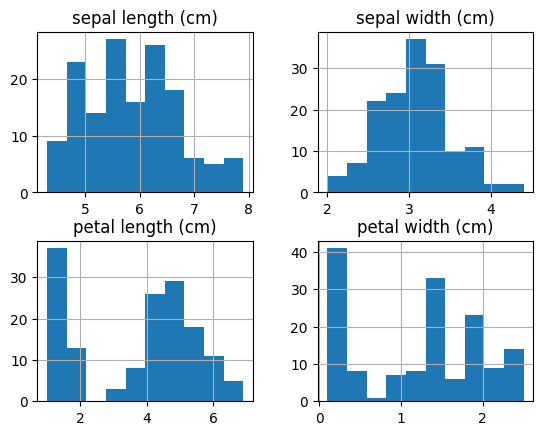

In [28]:
df.hist()


Det finns 150 datapunkter med 0 Null values. så jag behöver inte rensa något. värdena håller sig på ungefär samma skala och behövs troligen inte skalas om för tydligare svar vid klustringen. 
* I första kolumnen sepal length ser distrubitionen ut att delas in i tre grupper med ganska mycket spridning.

* I andra kolumnen septal width är gruppering otydligt med de flesta septal width mellan 2,5 och 3,5 cm. 

* tredje och fjärde kolumnerna är helt klart tydligare grupperade och kommer troligen vara mer användbara vid klustering. 



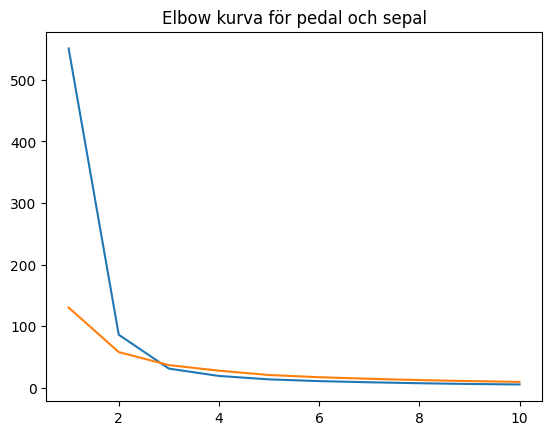

In [29]:
X=df[['petal length (cm)', 'petal width (cm)']]
b=df[['sepal length (cm)', 'sepal width (cm)']]

inertias=[]
inertias2=[]

for k in range(1,11):
    kmeans= KMeans(n_clusters=k, random_state=1, n_init=10)
    kmeans2= KMeans(n_clusters=k, random_state=1, n_init=10)
    
    kmeans.fit(X)
    kmeans2.fit(b)
    
    inertias.append(kmeans.inertia_)
    inertias2.append(kmeans2.inertia_)

plt.plot(range(1,11), inertias)
plt.plot(range(1,11), inertias2)
plt.title('Elbow kurva för pedal och sepal')

plt.show()


KMeans algoritm

kmeans är en algoritm som används för att gruppera datapunkter i kluster. Först bestäms antalet kluster som ska användas som är "k" (n_clusters).

Kmeans placerar sedan ut klustrerna med startpunkter som kallas för centroids vilket blir centrum för dessa kluster. Datapunkterna sätts sedan ut och tilldeas ett kluster beroende på hur nära dem är centroiderna. 

När alla punkter har blivit tilldelade ett kluster sätter algoritmen ut nya platser för centroiderna beroende på medelvärdet i varje kluster. Detta fortsätter tills kmeans har hittat den mest optimla platsen för centroiderna där datapunkterna är så nära centroiderna som möjligt eller max iterationer har upnåtts. (n_init) är hur många gånger centroiderna får ett nytt startvärde och gör om hela processen.


Antal kluster för blommorna

för att se hur många kluster som ska användas kan man använda en elbow graf som visar hur stor förbättringen blir med fler k (kluster). Ju fler k desto lägre blir inertia som ungefär är avståndet till centroiderna för datapunkterna. Men efter 3 k så blir förbättringen inte så stor så att välja 4 kluster är onödigt. Man kan även använda andra grafer som histogram eller scatterplots för att avgöra antal k. Efter att jag gjorde en elbow graf med datan av de som visade tydligast gruppering i histogrammen så kändes 3 kluster rimligast. 

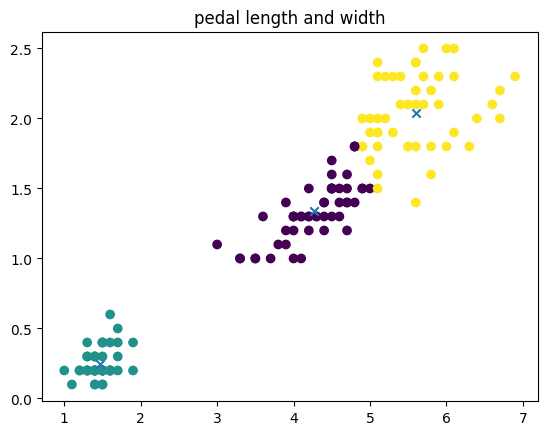

In [30]:
kmeans=KMeans(n_clusters=3, random_state=1, n_init=10)
groups= kmeans.fit_predict(X)
centers= kmeans.cluster_centers_
#print(X)
#print(centers)

centers=pd.DataFrame(centers)



plt.scatter(X.iloc[:, [0]], X.iloc[:, [1]], c=groups)
plt.scatter(centers.loc[:, [0]], centers.loc[:, [1]], marker='x')
plt.title('pedal length and width')

plt.show()

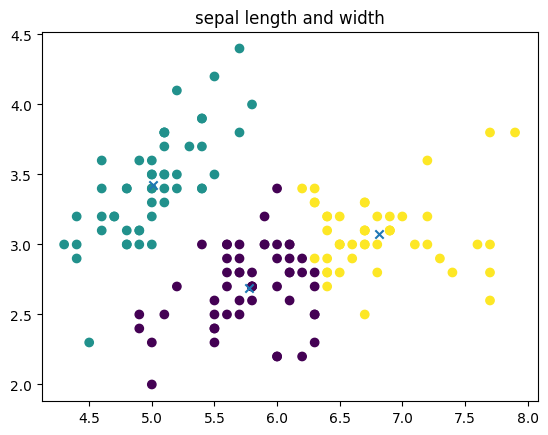

In [31]:
kmeans=KMeans(n_clusters=3, random_state=1, n_init=10)
groups= kmeans.fit_predict(b)
centers= kmeans.cluster_centers_
#print(b)
#print(centers)

centers=pd.DataFrame(centers)



plt.scatter(b.iloc[:, [0]], b.iloc[:, [1]], c=groups)
plt.scatter(centers.loc[:, [0]], centers.loc[:, [1]], marker='x')
plt.title('sepal length and width')

plt.show()

VG DEL:

[681.3706, 152.3479517603579, 78.85144142614601, 57.25600931571815, 46.44618205128205, 39.03998724608725, 34.46699028945883, 30.31643457686105, 28.3953335314571, 26.344124248558458]


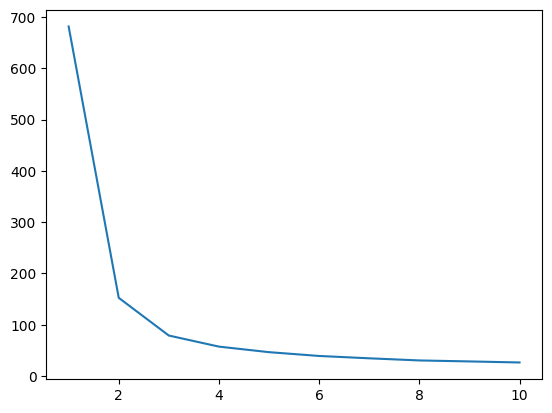

In [32]:
df= iris_df()


inertias=[]

for k in range(1,11):
    kmeans=KMeans(n_clusters=k, n_init=10, random_state=1)
    kmeans.fit(df)
    inertias.append(kmeans.inertia_)

print(inertias)

plt.plot(range(1,11), inertias)

plt.show()

ANTAL KLUSTER

I mitt fall ändrdes inte antalet valda kluster då elbow kurvan fortfarande visar att 3 kluster är det mest rimliga valet med alla attribut. 
Antalet kluster skiljer sig inte från tidigare uppgift då jag bara använde 2 attribut. Om jag hade använt de attributen med mindre tydlig gruppering så hade jag troligen valt 2 kluster i förra uppgift och då hade antal kluster skiljt sig. 

Principal Component Analysis

In [33]:
pca=PCA(n_components=2)
X_pca= pca.fit_transform(df)

X_pca= pd.DataFrame(
    {'PC1':X_pca[:, 0],
     'PC2':X_pca[:, 1]
    })
X_pca.head()



,PC1,PC2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755


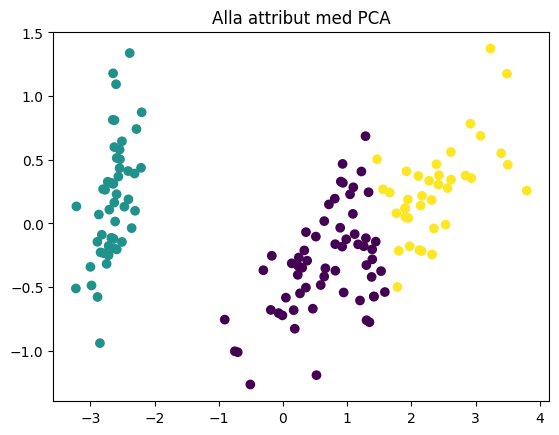

In [34]:
kmeans_all= KMeans(n_clusters=3, random_state=1, n_init=10)
groups= kmeans_all.fit_predict(df)
centers=kmeans_all.cluster_centers_

plt.scatter(X_pca['PC1'], X_pca['PC2'], c=groups)


plt.title('Alla attribut med PCA')
plt.show()

In [38]:


df_big= pd.read_csv('data collections/special_iris.csv')


print(df_big.shape)
print(df_big.nunique())
df_big.info()
print(df_big.head())

pca=PCA(n_components=2)
X_pca= pca.fit_transform(df_big)

X_pca= pd.DataFrame(
    {'PC1':X_pca[:, 0],
     'PC2':X_pca[:, 1]
    })
X_pca.head()

kmeans=KMeans(n_clusters=3, random_state=1, n_init=10)

groups= kmeans.fit_predict(df_big)



(1500000, 8)
sepal length (cm)     350000
sepal width (cm)      230000
petal length (cm)     430000
petal width (cm)      220000
extra sepal length    350000
extra sepal width     230000
extra petal length    430000
extra petal width     220000
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 8 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   sepal length (cm)   1500000 non-null  float64
 1   sepal width (cm)    1500000 non-null  float64
 2   petal length (cm)   1500000 non-null  float64
 3   petal width (cm)    1500000 non-null  float64
 4   extra sepal length  1500000 non-null  float64
 5   extra sepal width   1500000 non-null  float64
 6   extra petal length  1500000 non-null  float64
 7   extra petal width   1500000 non-null  float64
dtypes: float64(8)
memory usage: 91.6 MB
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          

I special iris.csv finns det 1.500 000 datapunkter med 8 attribut. De 4 sista attributen har ungefär samma mått som de 4 första fast med 3 decimaler istället för 1.

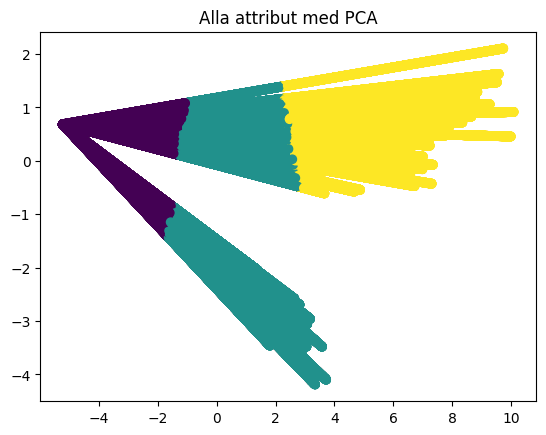

In [36]:
plt.scatter(X_pca['PC1'], X_pca['PC2'], c=groups)
plt.title('Alla attribut med PCA')
plt.show()

* I första klustringen med datasetet med 150 datatyper tog det 0 sekunder att klustra datapunkterna. 
* I andra dataset tog det 14 sekunder att klustra alla datapunkter. 

tiden skiljer sig eftersom datasettet inehåller betydligt fler datapunkter vilket gör att kmeans måste göra väldigt många fler beräkningar vid varje iteration. 
Detta är tydligt då storlekten på det första datasettet är runt 5 KB medans andra är nästan 92 MB. Kanske hade det gått snabbare om man ändrar datasetets datatyp till float 32 eller lägre. 



In [44]:

df_big_16=df_big.astype('float16')

df_big_16.info()



<class 'pandas.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 8 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   sepal length (cm)   1500000 non-null  float16
 1   sepal width (cm)    1500000 non-null  float16
 2   petal length (cm)   1500000 non-null  float16
 3   petal width (cm)    1500000 non-null  float16
 4   extra sepal length  1500000 non-null  float16
 5   extra sepal width   1500000 non-null  float16
 6   extra petal length  1500000 non-null  float16
 7   extra petal width   1500000 non-null  float16
dtypes: float16(8)
memory usage: 22.9 MB


Minnet gick från 92MB till 23MB men gav ingen försbättring av hur lång tid det tog att klustra. 